In [1]:
import matplotlib.pyplot as plt
import numpy as np

from easydynamics.convolution.analytical_convolution import AnalyticalConvolution
from easydynamics.convolution.numerical_convolution import NumericalConvolution
from easydynamics.sample_model import Gaussian
from easydynamics.sample_model.component_collection import ComponentCollection

C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_26972\1581469147.py:29: UserWarning: The width of the sample model component 'Gaussian_0' (30.0) is large compared to the span of the input array (100.0). This may lead to inaccuracies in the convolution. Increase extension_factor to improve accuracy.
  y_numerical = numerical_convolver.convolution()
C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_26972\1581469147.py:29: UserWarning: The width of the sample model component 'Gaussian_0' (20.0) is large compared to the span of the input array (100.0). This may lead to inaccuracies in the convolution. Increase extension_factor to improve accuracy.
  y_numerical = numerical_convolver.convolution()


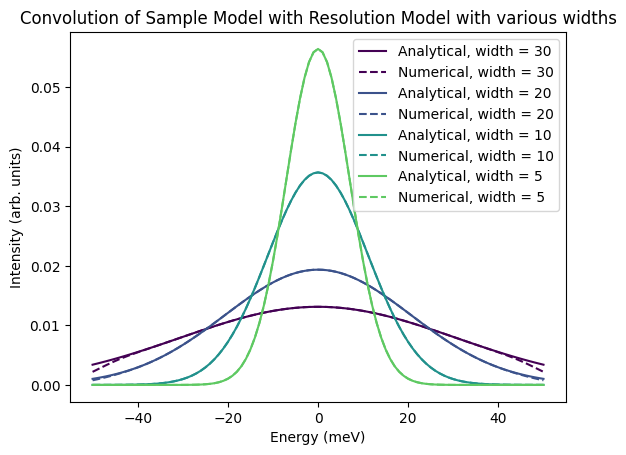

In [2]:
# When the width of the Gaussian is >~20% of the span,
# numerical issues arise. We set the limit to 10% to be safe.
gaussian_widths = [30, 20, 10, 5]
sample_components = ComponentCollection()
gaussian = Gaussian(display_name='Gaussian', width=30, area=1)
sample_components.append_component(gaussian)

resolution_components = ComponentCollection()
resolution_gaussian = Gaussian(display_name='Resolution Gaussian', width=5, area=1.0)
resolution_components.append_component(resolution_gaussian)
x = np.linspace(-50, 50, 101)

analytical_convolver = AnalyticalConvolution(
    sample_components=sample_components,
    resolution_components=resolution_components,
    energy=x,
)

numerical_convolver = NumericalConvolution(
    sample_components=sample_components,
    resolution_components=resolution_components,
    energy=x,
)
numerical_convolver.upsample_factor = None
for gwidth in gaussian_widths:
    sample_components[0].width = gwidth
    y_analytical = analytical_convolver.convolution()

    y_numerical = numerical_convolver.convolution()

    plt.plot(
        x,
        y_analytical,
        label=f'Analytical, width = {gwidth}',
        color=plt.cm.viridis(gaussian_widths.index(gwidth) / len(gaussian_widths)),
    )
    plt.plot(
        x,
        y_numerical,
        label=f'Numerical, width = {gwidth}',
        color=plt.cm.viridis(gaussian_widths.index(gwidth) / len(gaussian_widths)),
        linestyle='--',
    )
    plt.xlabel('Energy (meV)')
    plt.ylabel('Intensity (arb. units)')
    plt.title('Convolution of Sample Model with Resolution Model with various widths')

plt.legend()

C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_26972\514093336.py:31: UserWarning: The width of the sample model component 'Gaussian_2' (0.5) is small compared to the spacing of the input array (1.0). This may lead to inaccuracies in the convolution. Increase upsample_factor to improve accuracy.
  y_numerical = numerical_convolver.convolution()
C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_26972\514093336.py:31: UserWarning: The width of the sample model component 'Gaussian_2' (0.25) is small compared to the spacing of the input array (1.0). This may lead to inaccuracies in the convolution. Increase upsample_factor to improve accuracy.
  y_numerical = numerical_convolver.convolution()


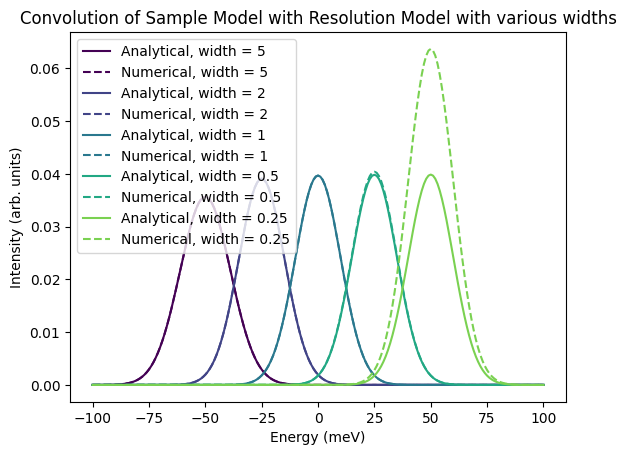

In [3]:
# When the width of the Gaussian is <~50% of the bin spacing,
# numerical issues arise. We set the limit to 100% to be safe.
gaussian_widths = [5, 2, 1, 0.5, 0.25]
gaussian_centers = [-50, -25, 0, 25, 50]
sample_components = ComponentCollection()
gaussian = Gaussian(display_name='Gaussian', width=0.5, area=1)
sample_components.append_component(gaussian)

resolution_components = ComponentCollection()
resolution_gaussian = Gaussian(display_name='Resolution Gaussian', width=10, area=1.0)
resolution_components.append_component(resolution_gaussian)
x = np.linspace(-100, 100, 201)

analytical_convolver = AnalyticalConvolution(
    sample_components=sample_components,
    resolution_components=resolution_components,
    energy=x,
)

numerical_convolver = NumericalConvolution(
    sample_components=sample_components,
    resolution_components=resolution_components,
    energy=x,
)
numerical_convolver.upsample_factor = None
for gwidth, gcenter in zip(gaussian_widths, gaussian_centers, strict=True):
    sample_components[0].width = gwidth
    sample_components[0].center = gcenter
    y_analytical = analytical_convolver.convolution()

    y_numerical = numerical_convolver.convolution()

    plt.plot(
        x,
        y_analytical,
        label=f'Analytical, width = {gwidth}',
        color=plt.cm.viridis(gaussian_widths.index(gwidth) / len(gaussian_widths)),
    )
    plt.plot(
        x,
        y_numerical,
        label=f'Numerical, width = {gwidth}',
        color=plt.cm.viridis(gaussian_widths.index(gwidth) / len(gaussian_widths)),
        linestyle='--',
    )
    plt.xlabel('Energy (meV)')
    plt.ylabel('Intensity (arb. units)')
    plt.title('Convolution of Sample Model with Resolution Model with various widths')

plt.legend()